# 3. Dimensionality Reduction

Import Packages

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## 3.1 Data Loading

Load the scaled datasets from 02_preprocessing_features

In [52]:
# ============================================================
# Load final scaled datasets
# ============================================================

X_A_scaled = pd.read_csv("../data/processed/X_A_scaled.csv")
X_B_scaled = pd.read_csv("../data/processed/X_B_scaled.csv")
X_C_scaled = pd.read_csv("../data/processed/X_C_scaled.csv")

print(X_A_scaled.shape)
print(X_B_scaled.shape)
print(X_C_scaled.shape)

(3595, 12)
(3505, 12)
(3350, 13)


## Dimensionality Reduction: Overview

The feature engineering process resulted in multiple transformed and scaled feature sets containing different aspects of Bitcoin market activity, valuation, mining, exchange flows and network demand.

Before starting with clustering and trying to find different regimes in Bitcoin time series, it is useful to first reduce the dimensionality of the data due to two reasons:

1) **Overlapping information**: Dimensionality Reduction methods do not remove overlapping information, but represent it in a lower-dimensional space, basically summarizing it into a smaller number of components. This reduces redundancy and noise while preserving most of the underlying information in the dataset.

2) **Mitigating the 'Curse of Dimensionality'**: The more dimensions a dataset has, the more possibilities each datapoint has to be further away from others. This results in higher distances, less close neighbours and generally more datapoints in solitude the higher the dimensions and generally leads to distorted results in clusters, or even with the possibility of not finding any clusters at all. For the case of my datasets, although the number of features is relatively small, dimensionality reduction helps reduce potential effects of the curse of dimensionality and improves the representation of the underlying data structure.

For Dimensionality Reduction two different approaches exist:

- Linear dimensionality reduction (e.g. PCA)
- Non-linear dimensionality reduction (e.g. UMAP, t-SNE)

Principal Component Analysis (PCA) transforms the original features into a smaller set of orthogonal components that explain as much variance in the data as possible. PCA is also highly interpretable and allows analysis of the underlying economic factors driving the dataset.

Non-linear methods aim to preserve the structure of the data in a lower-dimensional space without assuming linear relationships between variables. These methods can capture more complex patterns that may not be visible with PCA, and therefore could lead to potentially better results in clustering.

UMAP (Uniform Manifold Approximation and Projection) constructs a graph based on local neighborhoods of observations and then projects the data into a lower-dimensional space while preserving these relationships as closely as possible. Compared to PCA, UMAP can capture non-linear structures and often reveals cluster patterns more clearly. However, the resulting dimensions are generally not directly interpretable.

t-SNE (t-Distributed Stochastic Neighbor Embedding) follows a similar idea by preserving local similarities between observations. It is particularly useful for visualizing complex datasets in two dimensions, but it focuses primarily on visualization and does not preserve global relationships as well as UMAP. In addition, t-SNE does not naturally allow the projection of new observations and is generally less suitable as a preprocessing step for clustering.

In this project, PCA is applied to all feature sets and serves as the primary dimensionality reduction technique. Clustering algorithms are first evaluated on the PCA representations of all datasets. 
As a robustness check and to possibly enhance the results, the best-performing feature set will then additionally be reduced in dimensionality by using UMAP, followed by again the same clustering algorithms to investigate whether the non-linear embedding reveals additional market structure. 

Finally, t-SNE is used as a visualization tool to provide an intuitive two-dimensional representation of the discovered clusters.

The next steps for the dimensionality reduction with PCA are as follows:

1. Apply PCA to each feature set.
2. Analyze the explained variance and determine the appropriate number of principal components.
3. Explore the PCA loadings to understand which variables drive the resulting components.
4. Transform each dataset into its lower-dimensional PCA representation.

After these steps are taken, the PCA-transformed datasets are ready for the clustering algorithms.

## 3.3 PCA Dataset A

### PCA

In [53]:
# ============================================================
# PCA - Dataset A
# ============================================================

from sklearn.decomposition import PCA

X_A = X_A_scaled.drop(columns=["date"])

pca_A = PCA()

pca_A.fit(X_A)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

### Explained Varience

In [54]:
# ============================================================
# Explained Variance
# ============================================================

explained_variance_A = pd.DataFrame({
    "PC": range(1, len(pca_A.explained_variance_ratio_) + 1),
    "Explained Variance": pca_A.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(
        pca_A.explained_variance_ratio_
    )
})

explained_variance_A

,PC,Explained Variance,Cumulative Variance
0,1,0.457588,0.457588
1,2,0.168404,0.625992
2,3,0.100050,0.726042
3,4,0.078333,0.804375
4,5,0.056446,0.860820
5,6,0.044050,0.904870
6,7,0.038484,0.943354
7,8,0.026898,0.970252
8,9,0.013822,0.984074
9,10,0.011445,0.995519


### Scree Plot

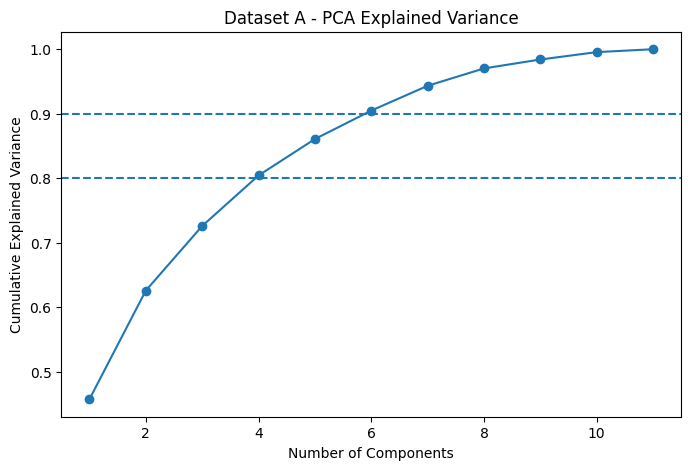

In [55]:
# ============================================================
# Scree Plot
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca_A.explained_variance_ratio_) + 1),
    np.cumsum(pca_A.explained_variance_ratio_),
    marker="o"
)

plt.axhline(
    y=0.80,
    linestyle="--"
)

plt.axhline(
    y=0.90,
    linestyle="--"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title(
    "Dataset A - PCA Explained Variance"
)

plt.show()

The first four principal components explain approximately 80% of the total variance, while six components explain more than 90%.

### PCA Loadings

In [56]:
# ============================================================
# PCA Loadings
# ============================================================

loadings_A = pd.DataFrame(
    pca_A.components_.T,
    index=X_A.columns,
    columns=[
        f"PC{i}"
        for i in range(
            1,
            len(X_A.columns) + 1
        )
    ]
)

loadings_A.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
active_addresses_ma30_g90d,0.326,0.276,-0.285,0.095,-0.271,-0.188,-0.406,0.539,-0.022,-0.045,-0.401
nonzero_addresses_ma30_g90d,0.327,-0.006,0.061,0.306,-0.340,0.717,-0.269,-0.293,-0.056,-0.018,0.069
transaction_count_ma30_g90d,0.139,0.564,0.421,-0.017,0.355,0.050,0.095,-0.270,-0.078,-0.018,-0.518
transfer_count_ma30_g90d,0.272,0.554,0.089,0.019,0.129,-0.108,-0.053,0.142,-0.036,0.083,0.743
hash_rate_ma30_g90d,0.179,-0.302,0.130,0.781,0.319,-0.339,-0.086,-0.041,-0.154,-0.004,0.014
exchange_supply_btc_ma30_g90d,0.030,-0.253,0.823,-0.207,-0.247,-0.122,-0.273,0.244,0.024,-0.042,0.049
exchange_outflow_usd_ma30_g90d,0.383,-0.101,-0.092,-0.262,-0.194,-0.287,0.124,-0.315,-0.505,-0.524,0.047
price_usd_ma30_g90d,0.393,-0.142,-0.071,-0.146,0.236,-0.087,-0.159,-0.190,0.765,-0.298,0.016
spot_volume_usd_ma30_g90d,0.394,-0.090,-0.010,-0.102,-0.282,-0.278,0.188,-0.270,0.078,0.741,-0.079
mvrv_ratio,0.280,-0.307,-0.101,-0.366,0.577,0.271,-0.256,0.189,-0.336,0.251,-0.011


### PCA Interpretation

Principal Components are new variables created as linear combinations of the original features. They represent the main directions of variation in the dataset, with each component capturing a different source of information. The loadings indicate how strongly each original feature contributes to a given component and can therefore be used to interpret its economic meaning.

The first principal component explains 45.8% of the total variance and is mainly driven by price growth, spot volume growth, exchange outflows, total fees and address activity. This suggests that the dominant source of variation in the dataset is related to overall trading activity and speculative demand, what is very reasonable given that it can be classified as a speculative asset.

The second principal component is primarily influenced by transaction count and transfer count, while showing an opposite relationship with valuation and mining-related variables. It possibly captures changes in transaction activity that are partly independent from overall market performance, probably showcasing the variation through usage-demand instead of pure trading- and speculation.

The third principal component is strongly associated with exchange supply, indicating that exchange balances contain information that is not fully captured by the other variables.

The fourth principal component is dominated by hash rate growth and can be interpreted as a mining-related factor.

In total, the first 4 principal components explain approximately 80% of the total variance, while 6 components explain more than 90%.

Overall, the PCA results suggest that the selected features capture multiple economic dimensions of the Bitcoin ecosystem instead of only reflecting a single demand or price factor.

### Conclusion

6 components, explaining 90.5% of the total variance in the dataset, will be selected for the clustering analysis. This decision provides a good balance between dimensionality reduction and information retention. While 4 components already explain approximately 80% of the variance, the additional two components increase the explained variance to over 90% and therefore keep a substantially larger share of the original structure of the data.

The PCA results also indicate that the feature engineering process was successful in preserving different sources of information, including market activity, exchange behaviour and mining dynamics.

### Create and Save New Features

In [57]:
# ============================================================
# Transform Dataset A to selected PCA components
# ============================================================

n_components_A = 6

pca_A_final = PCA(n_components=n_components_A)

X_A_pca_array = pca_A_final.fit_transform(
    X_A_scaled.drop(columns=["date"])
)

X_A_pca = pd.DataFrame(
    X_A_pca_array,
    columns=[f"PC{i}" for i in range(1, n_components_A + 1)]
)

X_A_pca["date"] = X_A_scaled["date"].values

print(X_A_pca.shape)
X_A_pca.head()

(3595, 7)


,PC1,PC2,PC3,PC4,PC5,PC6,date
0,-0.100973,-0.199143,2.021028,1.068027,-0.396304,-0.261407,2016-04-29
1,-0.182315,-0.223407,1.959695,1.051202,-0.419744,-0.232249,2016-04-30
2,-0.284514,-0.306394,1.893653,1.033505,-0.394547,-0.160873,2016-05-01
3,-0.306942,-0.373404,1.867155,1.043104,-0.429090,-0.080018,2016-05-02
4,-0.281560,-0.359377,1.843730,1.041143,-0.383857,-0.028122,2016-05-03


In [58]:
# ============================================================
# Save PCA Dataset A for clustering
# ============================================================

X_A_pca.to_csv(
    "../data/processed/X_A_pca_6components.csv",
    index=False
)

print("Saved PCA Dataset A for clustering.")

Saved PCA Dataset A for clustering.


## 3.4 PCA Dataset B

### PCA

In [59]:
# ============================================================
# PCA - Dataset B
# ============================================================

X_B = X_B_scaled.drop(columns=["date"])

pca_B = PCA()

pca_B.fit(X_B)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

### Explained Varience

In [60]:
# ============================================================
# Explained Variance
# ============================================================

explained_variance_B = pd.DataFrame({
    "PC": range(1, len(pca_B.explained_variance_ratio_) + 1),
    "Explained Variance": pca_B.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(
        pca_B.explained_variance_ratio_
    )
})

explained_variance_B

,PC,Explained Variance,Cumulative Variance
0,1,0.434227,0.434227
1,2,0.202012,0.636239
2,3,0.108368,0.744607
3,4,0.085586,0.830193
4,5,0.039200,0.869393
5,6,0.036461,0.905854
6,7,0.034869,0.940723
7,8,0.025334,0.966057
8,9,0.017555,0.983612
9,10,0.012442,0.996055


### Scree Plot

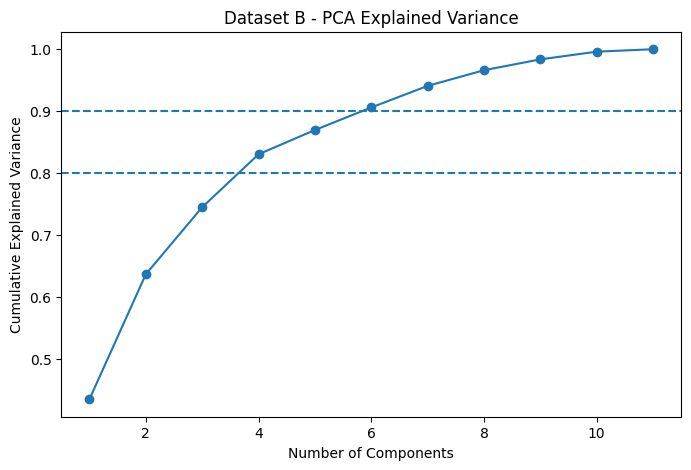

In [61]:
# ============================================================
# Scree Plot
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca_B.explained_variance_ratio_) + 1),
    np.cumsum(pca_B.explained_variance_ratio_),
    marker="o"
)

plt.axhline(
    y=0.80,
    linestyle="--"
)

plt.axhline(
    y=0.90,
    linestyle="--"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title(
    "Dataset B - PCA Explained Variance"
)

plt.show()

### PCA Loadings

In [62]:
# ============================================================
# PCA Loadings
# ============================================================

loadings_B = pd.DataFrame(
    pca_B.components_.T,
    index=X_B.columns,
    columns=[
        f"PC{i}"
        for i in range(
            1,
            len(X_B.columns) + 1
        )
    ]
)

loadings_B.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
active_addresses_ma30_g180d,0.298,0.357,-0.268,0.205,-0.021,-0.321,-0.046,0.647,0.074,-0.037,-0.372
nonzero_addresses_ma30_g180d,0.346,0.053,0.048,0.351,0.787,-0.166,0.047,-0.256,-0.122,0.110,0.100
transaction_count_ma30_g180d,0.043,0.528,0.480,-0.192,0.003,0.119,-0.193,-0.318,0.079,0.085,-0.535
transfer_count_ma30_g180d,0.202,0.575,0.136,-0.057,-0.175,-0.020,-0.125,0.061,0.064,0.024,0.743
hash_rate_ma30_g180d,0.195,-0.276,0.295,0.666,-0.334,0.144,-0.405,0.000,0.137,0.203,-0.003
exchange_supply_btc_ma30_g180d,0.039,-0.310,0.717,-0.267,0.163,-0.278,0.054,0.448,0.012,-0.060,0.082
exchange_outflow_usd_ma30_g180d,0.390,-0.132,-0.080,-0.275,-0.282,-0.263,0.131,-0.132,-0.337,0.671,-0.043
price_usd_ma30_g180d,0.403,-0.128,-0.042,-0.142,-0.136,-0.089,-0.372,-0.165,-0.477,-0.616,-0.037
spot_volume_usd_ma30_g180d,0.397,-0.107,0.019,-0.003,-0.210,-0.245,0.425,-0.316,0.607,-0.277,-0.031
mvrv_ratio,0.314,-0.204,-0.234,-0.428,0.262,0.335,-0.454,0.122,0.443,0.153,0.025


### PCA Interpretation

Generally, Dataset B produces very similar principal component structures to Dataset A, indicating that the results are robust across different growth time horizons. Dataset B showed a slightly more balanced distribution of explained variance between the principal components, suggesting that the longer growth horizon may capture economic regimes a bit more effective.

The principal components of Dataset B are analogous to the ones of A primarily driven by the same variables. In total, the first four principal components explain approximately 83.0% of the total variance, while six components explain more than 90%.

Overall, the PCA results suggest that the selected features capture several distinct economic dimensions of the Bitcoin ecosystem, including market activity, transaction behaviour, exchange dynamics and mining activity.

### Conclusion

As the results are very similar to the ones within Dataset A, 6 principal components, explaining 90.6% of the total variance in the dataset, will too be selected for the clustering analysis for the same reason as well as to enable direct comparison of the results.

Dataset A and Dataset B produced highly similar principal component structures, indicating that the results are robust across different growth horizons. Dataset B showed a slightly more balanced distribution of explained variance, suggesting that the longer growth horizon may capture economic regimes more effectively. I will test this hypothesis with the clustering.

### Create and Save New Features

In [63]:
# ============================================================
# PCA - Dataset B
# ============================================================

n_components_B = 6

pca_B_final = PCA(
    n_components=n_components_B
)

X_B_pca_array = pca_B_final.fit_transform(
    X_B_scaled.drop(columns=["date"])
)

X_B_pca = pd.DataFrame(
    X_B_pca_array,
    columns=[
        f"PC{i}"
        for i in range(1, n_components_B + 1)
    ]
)

X_B_pca["date"] = X_B_scaled["date"].values

print(X_B_pca.shape)

X_B_pca.head()

(3505, 7)


,PC1,PC2,PC3,PC4,PC5,PC6,date
0,0.635569,-1.120917,2.391120,0.084731,1.460830,-0.978507,2016-07-28
1,0.577643,-1.178828,2.346158,0.069774,1.505623,-0.949185,2016-07-29
2,0.473483,-1.249526,2.291411,0.068131,1.560131,-0.941195,2016-07-30
3,0.392634,-1.316739,2.286394,0.122032,1.573751,-0.903815,2016-07-31
4,0.363109,-1.282393,2.298845,0.154434,1.569899,-0.943250,2016-08-01


In [64]:
# ============================================================
# Save PCA Dataset B
# ============================================================

X_B_pca.to_csv(
    "../data/processed/X_B_pca_6components.csv",
    index=False
)

print("Saved PCA Dataset B for clustering.")

Saved PCA Dataset B for clustering.


## 3.5 PCA Dataset C

### PCA

In [65]:
# ============================================================
# PCA - Dataset C
# ============================================================

X_C = X_C_scaled.drop(columns=["date"])

pca_C = PCA()

pca_C.fit(X_C)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

### Explained Varience

In [66]:
# ============================================================
# Explained Variance - Dataset C
# ============================================================

explained_variance_C = pd.DataFrame({
    "PC": range(1, len(pca_C.explained_variance_ratio_) + 1),
    "Explained Variance": pca_C.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(
        pca_C.explained_variance_ratio_
    )
})

explained_variance_C

,PC,Explained Variance,Cumulative Variance
0,1,0.414743,0.414743
1,2,0.176156,0.590898
2,3,0.093534,0.684433
3,4,0.079562,0.763995
4,5,0.069624,0.833619
5,6,0.047354,0.880973
6,7,0.038251,0.919224
7,8,0.030767,0.949991
8,9,0.021791,0.971782
9,10,0.012852,0.984634


### Scree Plot

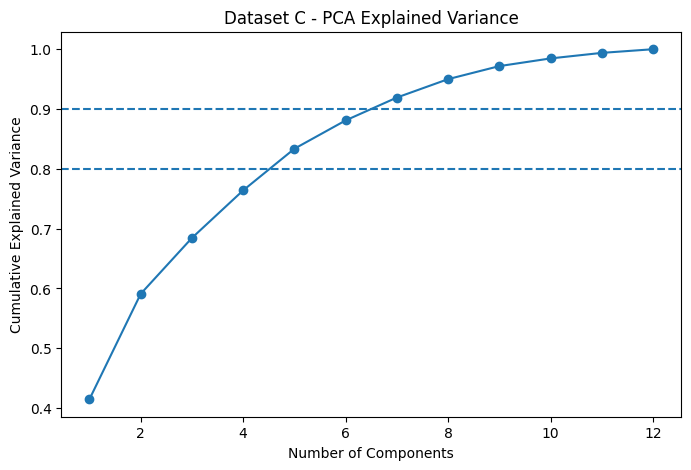

In [67]:
# ============================================================
# Scree Plot - Dataset C
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(pca_C.explained_variance_ratio_) + 1),
    np.cumsum(pca_C.explained_variance_ratio_),
    marker="o"
)

plt.axhline(
    y=0.80,
    linestyle="--"
)

plt.axhline(
    y=0.90,
    linestyle="--"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Dataset C - PCA Explained Variance")

plt.show()

### PCA Loadings

In [68]:
# ============================================================
# PCA Loadings - Dataset C
# ============================================================

loadings_C = pd.DataFrame(
    pca_C.components_.T,
    index=X_C.columns,
    columns=[
        f"PC{i}"
        for i in range(1, len(X_C.columns) + 1)
    ]
)

loadings_C.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
active_addresses_z365d,0.305,0.282,-0.154,-0.051,-0.359,-0.007,0.225,0.744,-0.018,-0.006,0.100,-0.242
nonzero_addresses_z365d,0.224,0.192,-0.325,0.244,0.638,0.284,0.482,-0.073,0.056,-0.114,0.072,-0.040
transaction_count_z365d,0.163,0.519,0.349,-0.167,0.191,-0.257,-0.178,-0.262,-0.081,-0.079,0.110,-0.572
transfer_count_z365d,0.260,0.507,0.142,-0.151,0.111,-0.154,-0.104,0.070,-0.003,-0.001,-0.215,0.731
hash_rate_z365d,0.198,0.090,0.454,0.584,-0.426,0.217,0.218,-0.230,0.083,-0.255,0.016,0.069
issuance_usd_z365d,0.366,-0.210,0.190,0.274,0.140,-0.157,0.041,0.054,-0.088,0.708,-0.371,-0.127
exchange_supply_btc_z365d,0.005,-0.329,0.626,-0.437,0.225,0.056,0.433,0.207,0.037,-0.111,0.087,0.060
exchange_outflow_usd_z365d,0.349,-0.107,-0.206,-0.300,-0.206,-0.175,0.152,-0.298,0.726,-0.016,-0.133,-0.063
price_usd_z365d,0.373,-0.249,0.003,0.170,0.119,-0.271,-0.246,0.042,0.049,0.034,0.763,0.186
spot_volume_usd_z365d,0.337,-0.085,-0.206,-0.329,-0.287,0.059,0.267,-0.396,-0.634,0.041,0.079,0.063


### PCA Interpretation

Dataset C also produces a principal component structure that is broadly similar to Dataset A and Dataset B. The main economic dimensions identified previously, including market activity, transaction behaviour, exchange dynamics and mining activity, are still clearly visible in the first principal components.

However, compared to the growth-based datasets, the explained variance is distributed more evenly across the components. The first principal component explains only 41.5% of the total variance, compared to 45.8% and 43.4% in Dataset A and Dataset B respectively. As a result, more principal components are required to capture the same amount of information.

This behaviour is expected, as rolling Z-scores measure deviations from historical norms rather than long-term growth trends, while also compared to the Z-scores the growth rates were based on a smoothed Moving-Average transformation prior. As a result, variables such as fees, issuance value and exchange activity that are more volatile in their raw form contain more unique information in the Dataset C and are less absorbed into a single dominant market activity factor.

In total, the first five principal components explain approximately 83.4% of the total variance, while seven components explain more than 90%.

Overall, the PCA results suggest that the rolling Z-score transformation captures a broader set of abnormal market conditions and distributes information more evenly across different economic dimensions of the Bitcoin ecosystem.

### Conclusion

In contrast to Dataset A and Dataset B, Dataset C requires seven principal components to exceed the 90% explained variance threshold. Therefore, seven components, explaining 91.9% of the total variance, will be selected for the clustering analysis.

While the overall principal component structure remains similar to the growth-based datasets, the rolling Z-score transformation appears to preserve more variable-specific information and focuses less on a single dominant factor. This suggests that Dataset C may be especially useful for identifying unusual market conditions and abnormal regime behaviour.

The effectiveness of this alternative representation will be evaluated during the clustering analysis and compared directly with the results of Dataset A and Dataset B.


### Create and Save New Features

In [69]:
# ============================================================
# PCA - Dataset C
# ============================================================

n_components_C = 7

pca_C_final = PCA(
    n_components=n_components_C
)

X_C_pca_array = pca_C_final.fit_transform(
    X_C_scaled.drop(columns=["date"])
)

X_C_pca = pd.DataFrame(
    X_C_pca_array,
    columns=[
        f"PC{i}"
        for i in range(1, n_components_C + 1)
    ]
)

X_C_pca["date"] = X_C_scaled["date"].values

print(X_C_pca.shape)

X_C_pca.head()

(3350, 8)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,date
0,2.760673,1.450773,-0.222554,0.465017,-0.407770,-0.548977,-0.079881,2016-12-30
1,1.121763,0.656433,-0.163385,1.338528,0.446082,-0.245689,-0.588865,2016-12-31
2,0.512296,-1.126331,-0.526675,2.010090,0.294701,0.268156,-0.289842,2017-01-01
3,3.346274,2.000051,0.044903,0.388717,-0.394146,-0.663846,-0.127804,2017-01-02
4,3.656829,2.245974,0.441155,0.316081,-0.150409,-0.892561,-0.335713,2017-01-03


In [70]:
# ============================================================
# Save PCA Dataset C
# ============================================================

X_C_pca.to_csv(
    "../data/processed/X_C_pca_7components.csv",
    index=False
)

print("Saved PCA Dataset C for clustering.")

Saved PCA Dataset C for clustering.


## 3.6 PCA Results Comparison

| Dataset   | Transformation         | PC1   | 4 PCs | 6 PCs | Components for >90% Variance |
| --------- | ---------------------- | ----- | ----- | ----- | ---------------------------- |
| Dataset A | 90d Growth             | 45.8% | 80.4% | 90.5% | 6                            |
| Dataset B | 180d Growth            | 43.4% | 83.0% | 90.6% | 6                            |
| Dataset C | Rolling Z-Score (365d) | 41.5% | 76.4% | 88.1% | 7                            |

The PCA results show a very similar structure across all three datasets. In all cases, the first four principal components capture information related to market activity, transaction behaviour, exchange dynamics and mining activity. This suggests that the main economic dimensions of the Bitcoin ecosystem are preserved regardless of the chosen feature transformation.

Dataset A and Dataset B produce nearly identical results. However, Dataset B explains slightly more variance within the first four principal components, suggesting that the longer 180-day growth horizon may capture market regimes somewhat more effectively.

Dataset C shows a different behaviour. The rolling Z-score transformation distributes the variance more evenly across the principal components and therefore requires seven components to exceed the 90% explained variance threshold. This indicates that the Z-score transformation preserves more feature-specific and anomaly-related information, while the growth-based datasets concentrate a larger share of the variance into fewer common factors.

Overall, all three datasets keep meaningful economic structure and provide a suitable basis for the next step: clustering -> 04_clustering
